# Detecting mis-identified peptides with PFNet

This notebook shows how PFNet can help diagnose peptide mis-identification in an HX-MS dataset. We start from the example dataset, intentionally swap the timepoints of two peptides to create a controlled error, then run PFNet and inspect the local uptake behavior to see how the suspicious peptides stand out.

In this tutorial you will:
1. Load the example dataset and create a dataset with two swapped peptide identities.
2. Run PFNet inference on the modified dataset.
3. Inspect uptake curves for the affected peptides and their neighbors.
4. Use the local fit pattern to understand how PFNet can help flag possible peptide mis-identification.


In [1]:
from copy import copy
from pathlib import Path

import matplotlib.pyplot as plt
from pigeon_feather.hxio import write_HXMS_files
from pigeon_feather.plot import UptakePlot

from pfnet.run_inference import _load_data, predict

Determination of memory status is not supported on this 
 platform, measuring for memoryleaks will never fail


## Load the source dataset

We begin from the same example HX-MS dataset used in the main PFNet tutorial. The next few cells modify this dataset in a controlled way so we can study how PFNet behaves when peptide identities are wrong.


In [2]:
source_input_path = Path("../examples/EEHEEEEHEE_rd4_0871.hxms")
dataset, batch, hxms_data = _load_data(str(source_input_path), centroid_model=False)

all_peptides = [peptide for state in hxms_data.states for peptide in state.peptides]
len(all_peptides)

Number of peptides with experimental max_d: 68
Number of peptides with no experimental max_d: 0
Skipping 0 peptides


68

## Create a dataset with swapped peptide identities

To simulate peptide mis-identification, we swap the timepoints of two peptides while leaving the peptide labels in place. This creates a mismatch between the observed uptake behavior and the expected local behavior of the surrounding sequence.


In [3]:
swap_idx_1 = 4
swap_idx_2 = 45

swapped_ids = (all_peptides[swap_idx_1].id, all_peptides[swap_idx_2].id)
swapped_ids

('1-14 GSHMTQVHVDGVTY', '18-28 NPEEAKKFADE')

In [4]:
timepoints_1 = copy(all_peptides[swap_idx_1].timepoints)
timepoints_2 = copy(all_peptides[swap_idx_2].timepoints)

all_peptides[swap_idx_1].timepoints = timepoints_2
all_peptides[swap_idx_2].timepoints = timepoints_1

for tp in all_peptides[swap_idx_1].timepoints:
    tp.peptide = all_peptides[swap_idx_1]
for tp in all_peptides[swap_idx_2].timepoints:
    tp.peptide = all_peptides[swap_idx_2]

## Write the modified HX-MS file

We export the altered dataset so PFNet can read it as a normal input file.


In [5]:
write_HXMS_files([hxms_data], "GR1_missid")

input_path = Path("./GR1_missid_Expt..hxms")
output_path = Path("./pfnet_output_GR1_missid")
output_path.mkdir(parents=True, exist_ok=True)

input_path, output_path

Wrote ./GR1_missid_Expt..hxms


(PosixPath('GR1_missid_Expt..hxms'), PosixPath('pfnet_output_GR1_missid'))

## Run PFNet inference

This run asks PFNet to explain a dataset that now contains two intentionally mis-identified peptides. The goal is not to recover the true identities automatically, but to see whether the resulting fit pattern makes the problematic peptides easier to spot.


In [6]:
output = predict(
    input=str(input_path),
    output_json=str(output_path / "pfnet_results.json"),
    centroid_model=False,
    refinement=False,
    uptake_plots=True,
    plots_dir=str(output_path / "uptake_plots"),
    benchmark=False,
)

loading PFNet model
Number of peptides with experimental max_d: 68
Number of peptides with no experimental max_d: 0
Skipping 0 peptides
plotting uptake plots


## Define peptide neighborhoods around the swapped peptides

To inspect the effect locally, we gather a few peptides around each swapped peptide. If the identities are wrong, the mismatched uptake behavior should be easiest to recognize in the context of nearby overlapping peptides.


In [7]:
idf_list1 = [pep.id for pep in all_peptides[1:7]]
idf_list2 = [pep.id for pep in all_peptides[42:48]]

idf_list1, idf_list2

(['1-10 GSHMTQVHVD',
  '1-11 GSHMTQVHVDG',
  '1-13 GSHMTQVHVDGVT',
  '1-14 GSHMTQVHVDGVTY',
  '1-15 GSHMTQVHVDGVTYT',
  '1-18 GSHMTQVHVDGVTYTFSN'],
 ['17-24 SNPEEAKK',
  '17-25 SNPEEAKKF',
  '17-28 SNPEEAKKFADE',
  '18-28 NPEEAKKFADE',
  '19-28 PEEAKKFADE',
  '20-28 EEAKKFADE'])

### Inspect the first local neighborhood

The plots below compare experiment and PFNet reconstruction for peptides near the first swapped peptide.


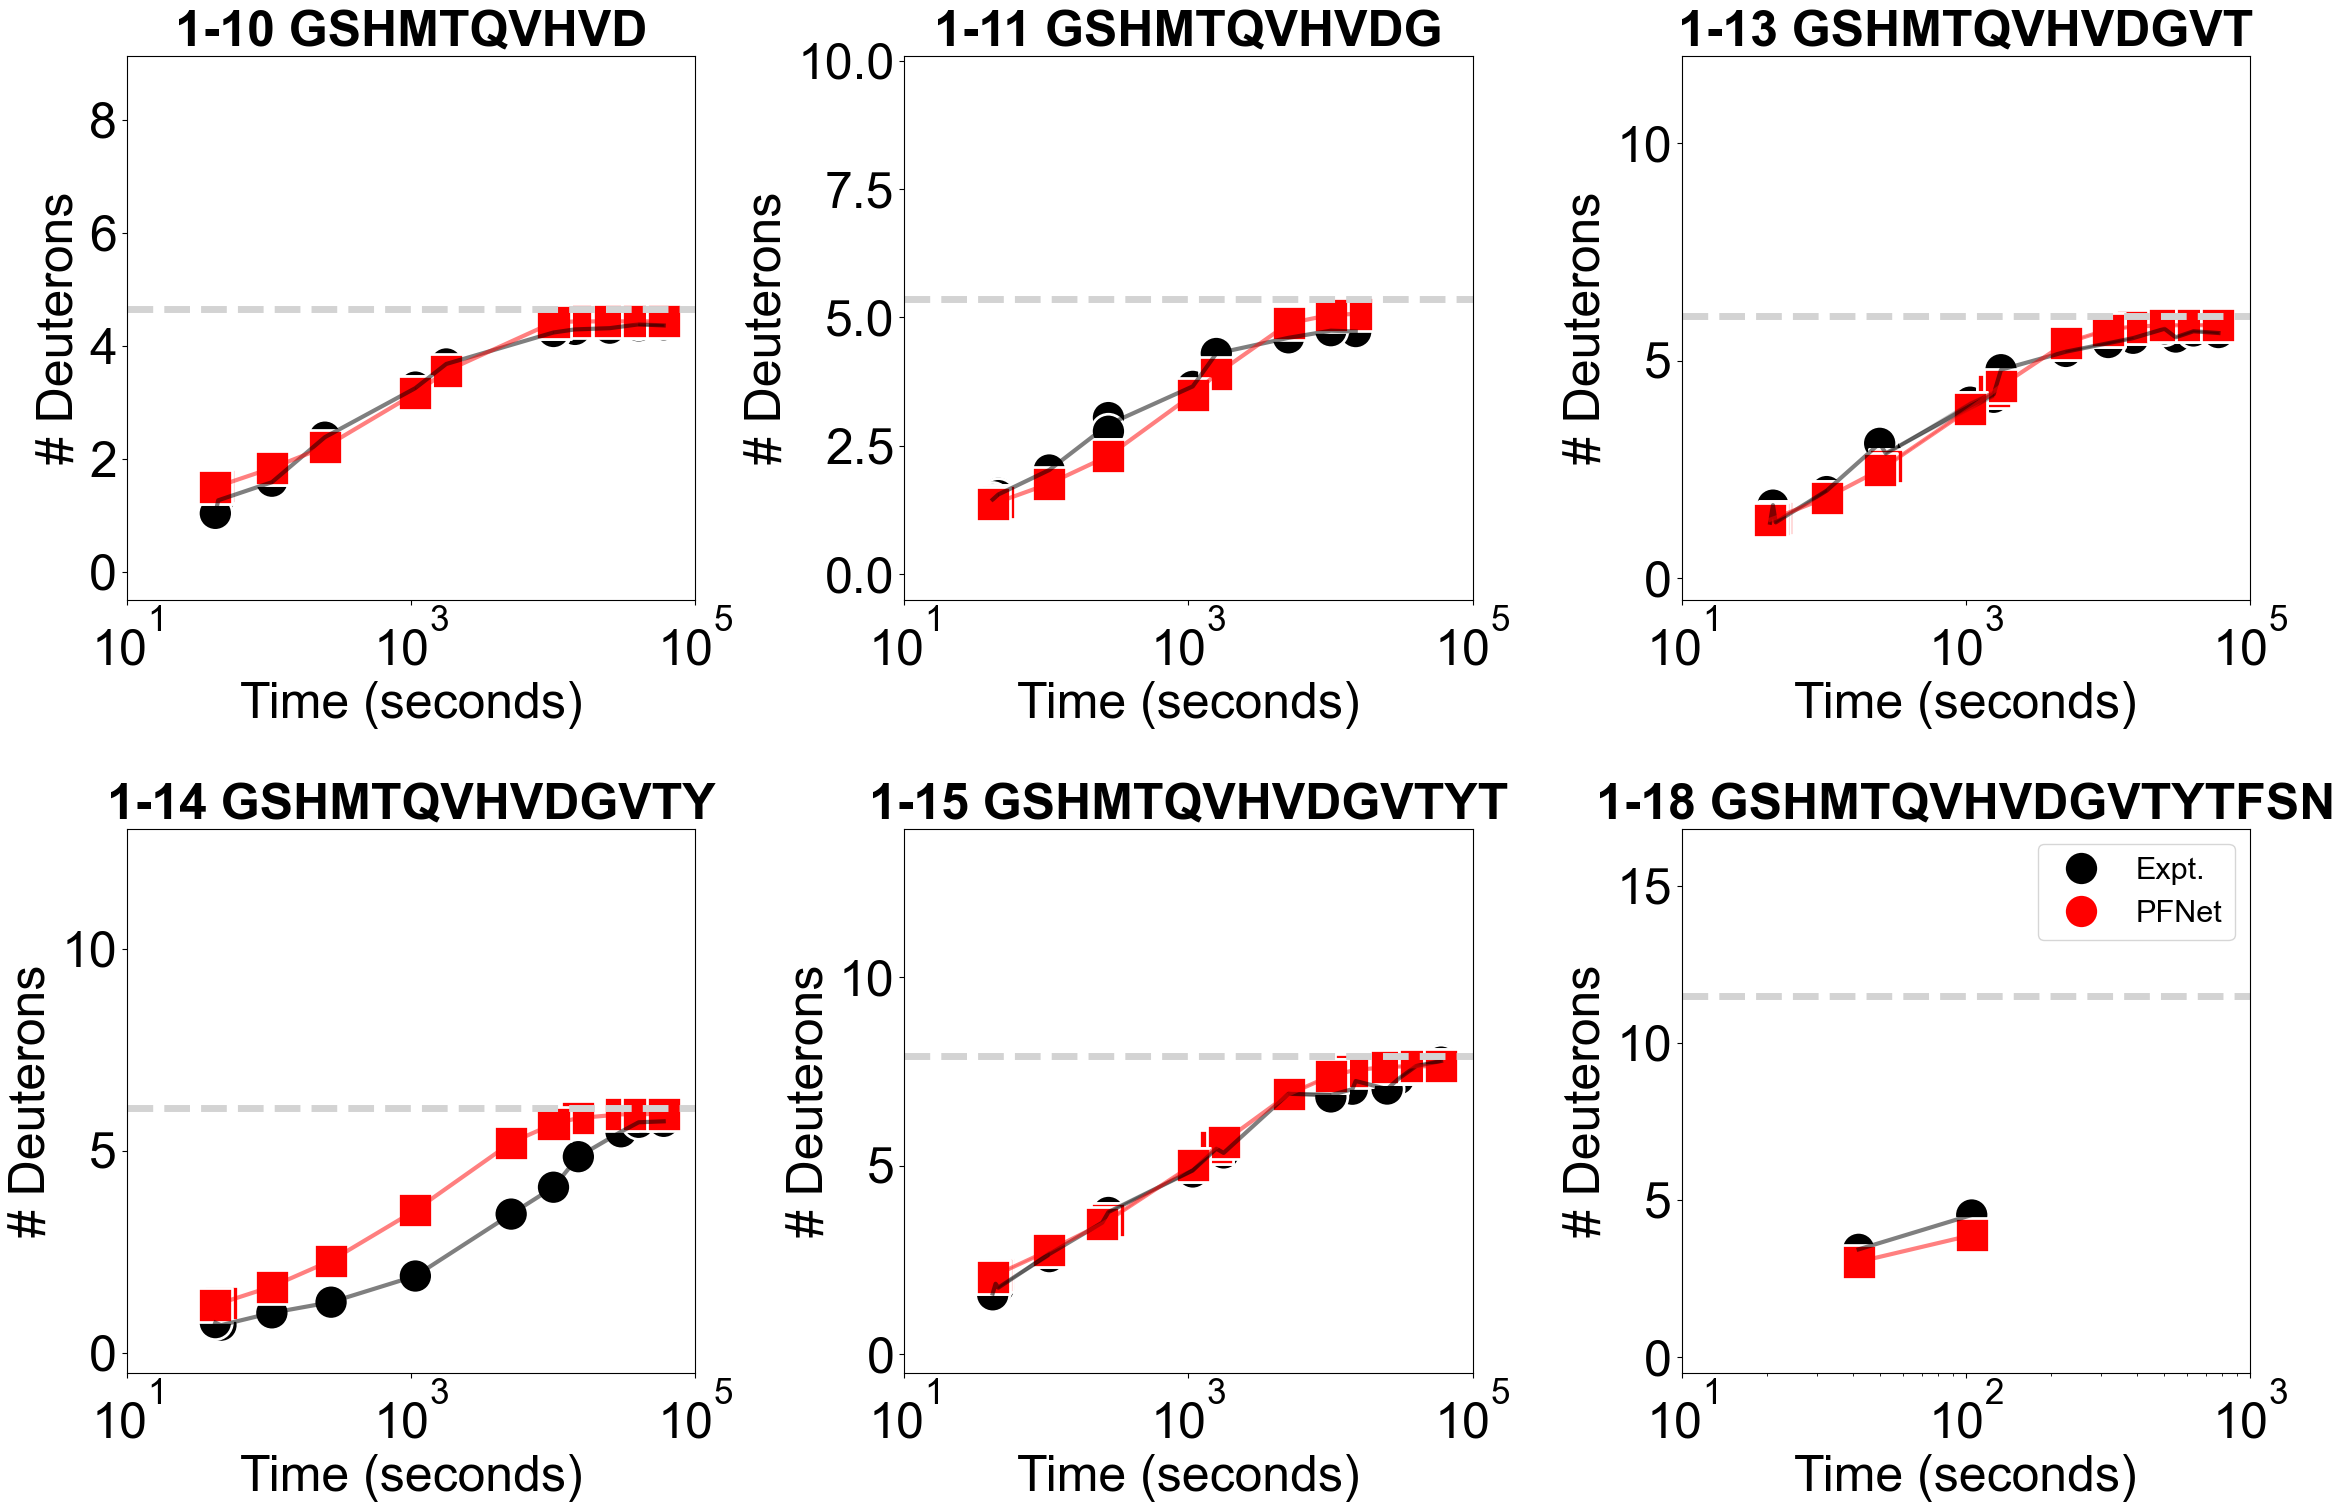

In [8]:
hdxms_data_list = [
    output["hdxms_data_objs"]["hdxms_data_expt"],
    output["hdxms_data_objs"]["hdxms_data_pfnet"],
]

fig, axes = plt.subplots(2, 3, figsize=(24, 16))
for i, peptide_id in enumerate(idf_list1):
    ax = axes.flatten()[i]
    peptide = [p for p in all_peptides if p.id == peptide_id][0]
    UptakePlot(
        hdxms_data_list,
        peptide_id,
        if_plot_fit=False,
        figure=fig,
        ax=ax,
        calculate_num_d_from_envelope=True,
    )
    ax.axhline(y=peptide.max_d, color="lightgray", linestyle="--", linewidth=5)
    y_max = peptide.theo_max_d / 0.9
    ax.set_ylim(-0.5, y_max + 0.5)

    if i == len(idf_list1) - 1:
        exclude_states = ["state", "data_set_index", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10"]
        handles, labels = ax.get_legend_handles_labels()
        new_labels = [label for label in labels if label not in exclude_states]
        new_handles = [handle for handle, label in zip(handles, labels) if label not in exclude_states]
        ax.legend(new_handles, new_labels, title="", title_fontsize="small", loc="best")
    else:
        ax.legend().remove()

fig.tight_layout()
fig

### Inspect the second local neighborhood

We repeat the same comparison for peptides near the second swapped peptide.


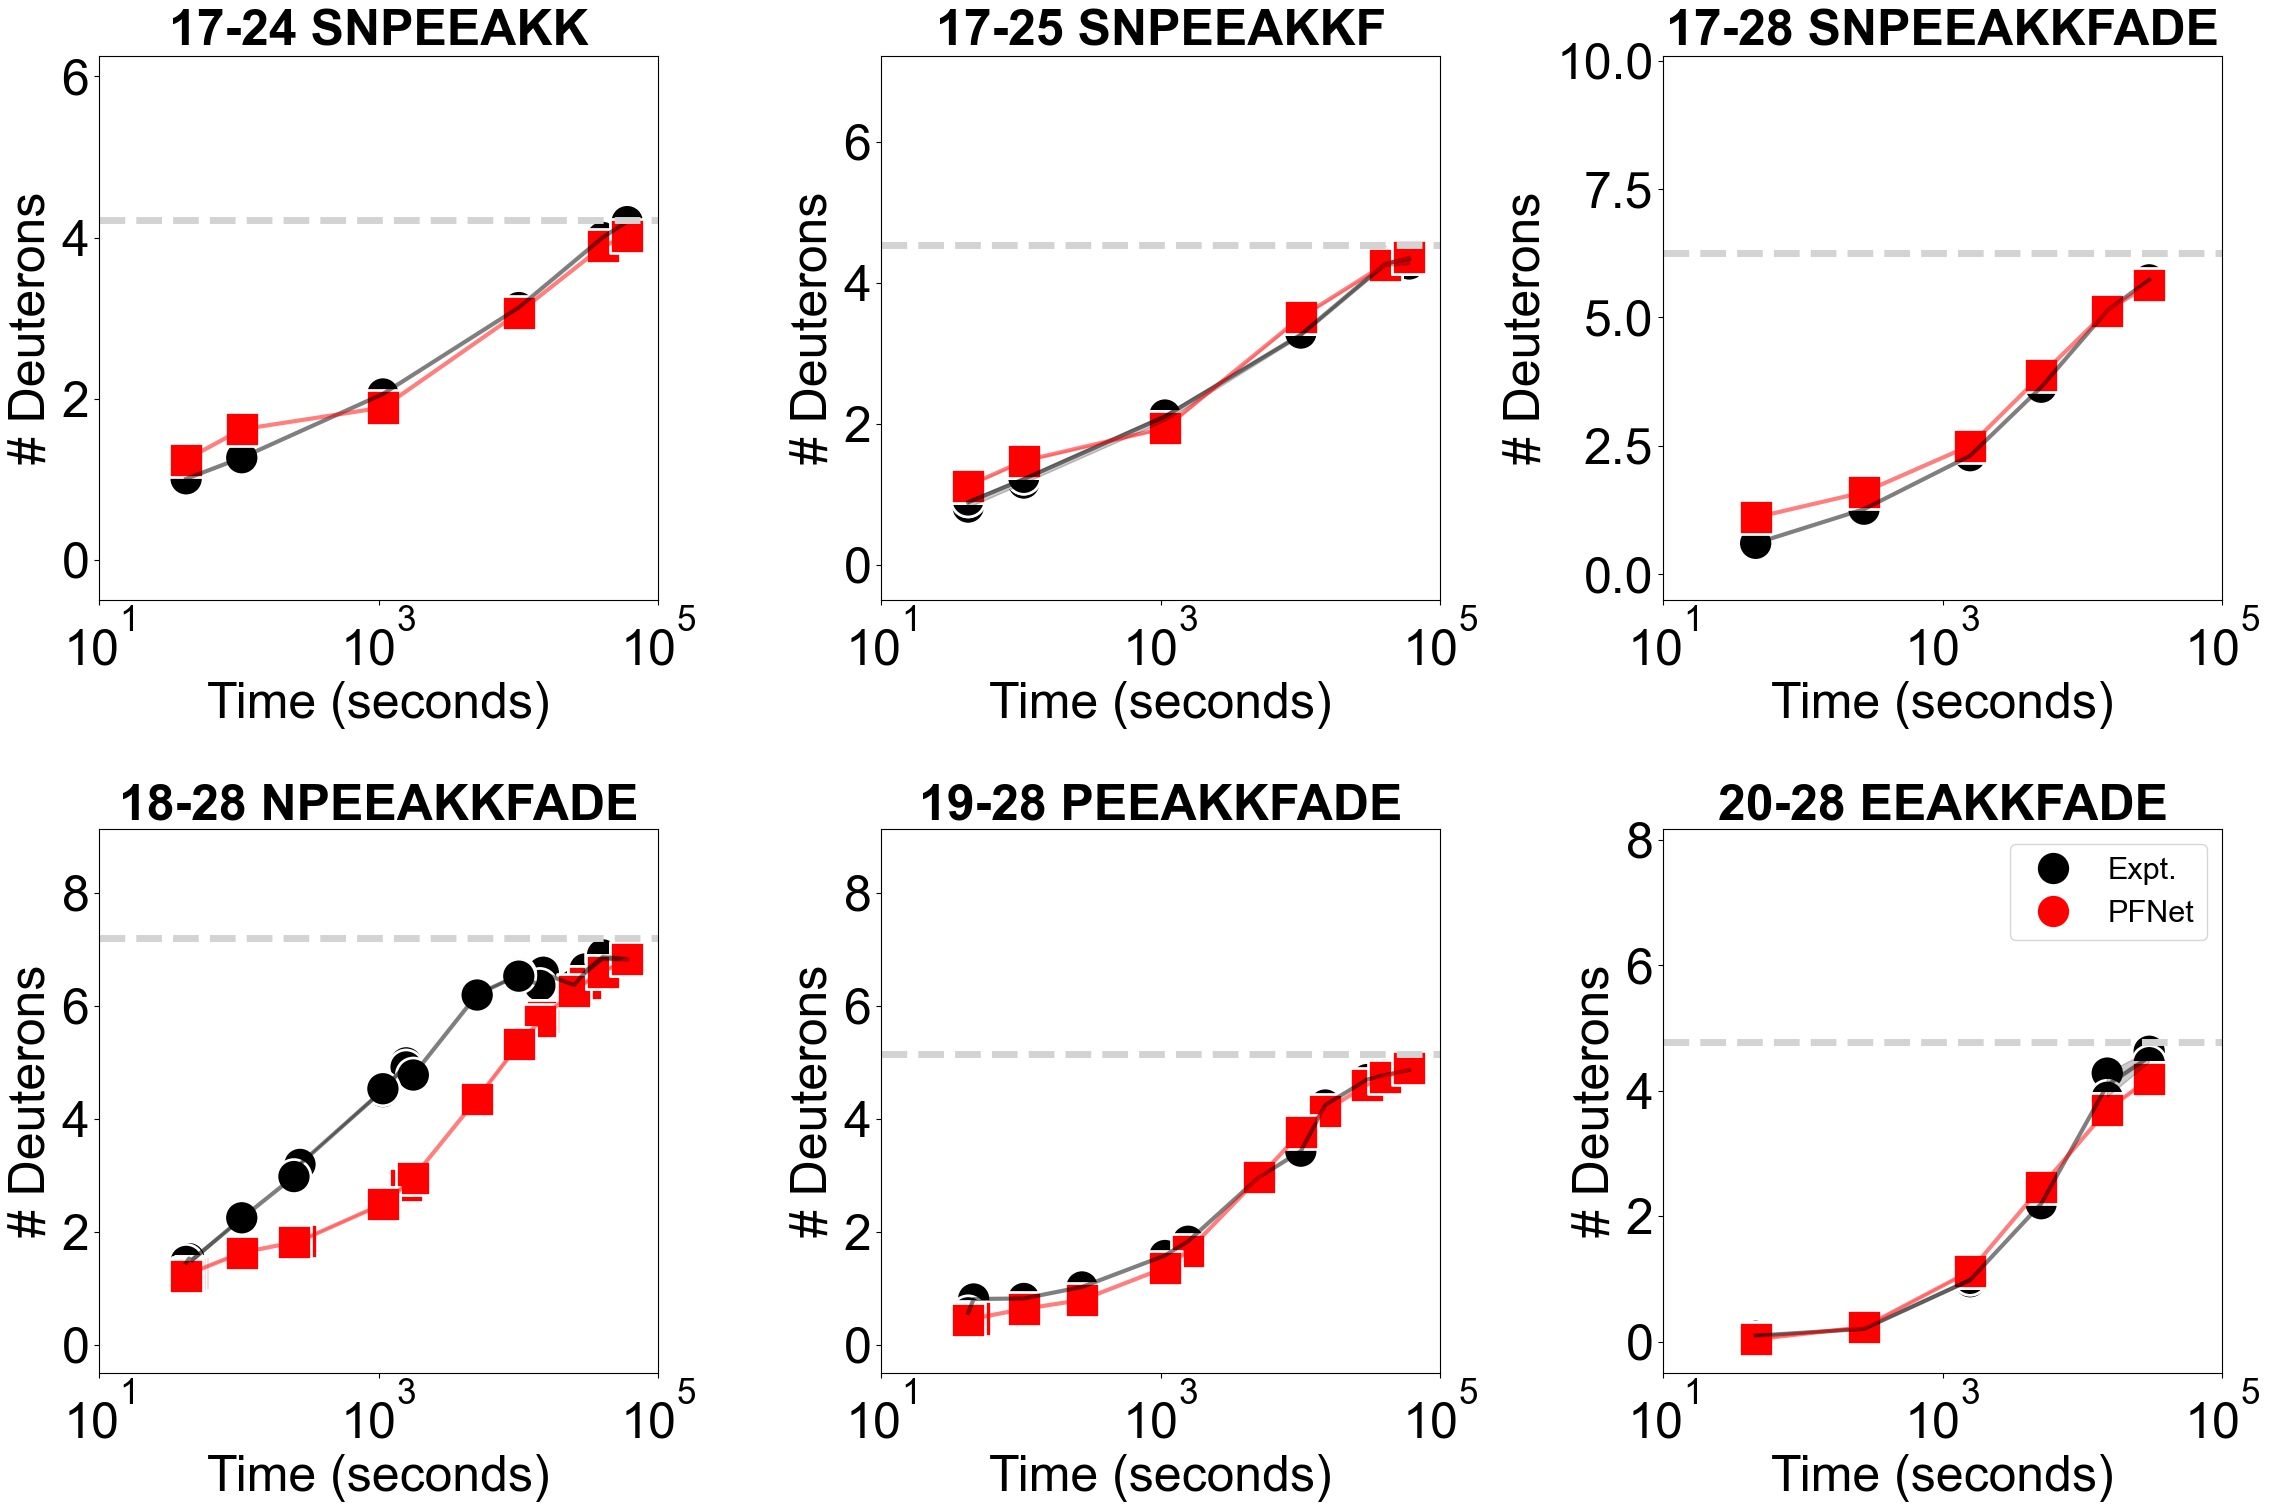

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(24, 16))
for i, peptide_id in enumerate(idf_list2):
    ax = axes.flatten()[i]
    peptide = [p for p in all_peptides if p.id == peptide_id][0]
    UptakePlot(
        hdxms_data_list,
        peptide_id,
        if_plot_fit=False,
        figure=fig,
        ax=ax,
        calculate_num_d_from_envelope=True,
    )
    ax.axhline(y=peptide.max_d, color="lightgray", linestyle="--", linewidth=5)
    y_max = peptide.theo_max_d / 0.9
    ax.set_ylim(-0.5, y_max + 0.5)

    if i == len(idf_list1) - 1:
        exclude_states = ["state", "data_set_index", "1", "2", "3", "4", "5", "6", "7", "8", "9", "10"]
        handles, labels = ax.get_legend_handles_labels()
        new_labels = [label for label in labels if label not in exclude_states]
        new_handles = [handle for handle, label in zip(handles, labels) if label not in exclude_states]
        ax.legend(new_handles, new_labels, title="", title_fontsize="small", loc="best")
    else:
        ax.legend().remove()

fig.tight_layout()
fig

## Interpreting the mismatch pattern

An important observation is that PFNet is somewhat robust to misidentified peptides. Rather than forcing the entire surrounding region to conform to an incorrect peptide assignment, a misassigned peptide appears to have only a limited impact, although this may not always be the case. In practice, that means the suspicious peptides can stand out because their uptake behavior and PFNet reconstruction look inconsistent with nearby overlapping peptides.

This is useful for quality control: a peptide with an unusually poor local fit, especially when its neighbors behave coherently, is a good candidate for manual review of peptide identification.


## Summary

This notebook demonstrates a simple strategy for using PFNet to help detect possible peptide mis-identification. By comparing local uptake fits around suspicious peptides, you can often identify peptides whose behavior is inconsistent with the surrounding region and prioritize them for further inspection.
